# Real-data diffPIR posterior samples

Save `.eps` panels of individual **diffPIR posterior samples** for shot 85270 at one time slice, as plotted in `experimental_data_analysis.ipynb` (cell using `posterior_tomo[10, ii, 0]`). Everything is loaded from the saved arrays; nothing is recomputed.

- source array: `posterior_tomo_core_mask_sigma025.npy` (28 slices x 100 samples)
- time slice: index 10 (t = 0.66 s)
- samples: the notebook plots the 11 samples `idxs_ptm = arange(28)[6::2]`; here we keep **samples 2 to 8** of those (numbered 1-11), i.e. sample indices [8, 10, 12, 14, 16, 18, 20]

In [1]:
%cd ../..

/home/fusiontomo/Repos/diffusion_tomography


In [2]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import scipy.io as scio
from scipy import ndimage

from reaction_diffusion.routines.tomo_fusion.tools import plotting_fcts as tomo_plots

figs_dir = Path("results_images/real_data_posterior_samples/figs")
figs_dir.mkdir(parents=True, exist_ok=True)


def preprocess_magnetic_data(data_exp, Nz, Nr, doublet=False):
    # interpolate original equilibria on the prescribed inversion grid
    eqs = np.zeros((data_exp["psi"].shape[2], Nz, Nr))
    rs = data_exp['liuqe_rs'][:, 0]
    zs = data_exp['liuqe_zs'][:, 0]
    dr_liuqe = np.mean(np.diff(rs.flatten()))
    dz_liuqe = np.mean(np.diff(zs.flatten()))
    tcv_zmin, tcv_zmax = -0.75, 0.75
    tcv_rmin, tcv_rmax = 0.624, 1.1376
    dz, dr = (tcv_zmax - tcv_zmin) / Nz, (tcv_rmax - tcv_rmin) / Nr
    tcv_Zs = np.linspace(tcv_zmin, tcv_zmax, Nz + 1, endpoint=True)[:-1] + dz / 2
    tcv_Rs = np.linspace(tcv_rmin, tcv_rmax, Nr + 1, endpoint=True)[:-1] + dr / 2
    for i in range(data_exp['psi'].shape[2]):
        r_pos_evals = (tcv_Rs - rs.min()) / dr_liuqe
        z_pos_evals = -(np.flip(tcv_Zs) - zs.max()) / dz_liuqe
        coord_eval_pos = np.zeros((2, Nz * Nr))
        for nz in range(Nz):
            for nr in range(Nr):
                coord_eval_pos[0, nr + nz * Nr] = z_pos_evals[nz]
                coord_eval_pos[1, nr + nz * Nr] = r_pos_evals[nr]
        if doublet:
            eqs[i, :, :] = ndimage.map_coordinates(np.flip(data_exp['psi'][:, :, i], axis=0),
                                                   coord_eval_pos, order=2, mode="nearest",
                                                   prefilter=True).reshape(Nz, Nr)
        else:
            eqs[i, :, :] = ndimage.map_coordinates(np.flip(data_exp['psi'][:, :, i].T, axis=0),
                                                   coord_eval_pos, order=2, mode="nearest",
                                                   prefilter=True).reshape(Nz, Nr)
    return eqs


def save_profile_eps(img, psi_slice, fname, cmap="viridis", vmin=None, vmax=None):
    # single-panel figure, saved as eps (same style as results_images/prior_samples)
    plt.figure(figsize=(3, 3))
    tomo_plots.plot_profile(np.asarray(img), tcv_plot_clip=True,
                            contour_image=psi_slice, cmap=cmap, ax=None,
                            colorbar=False, contour_color="w", vmin=vmin, vmax=vmax,
                            aspect=None, lcfs_width=1, lwidth=0.2)
    plt.axis('off')
    plt.savefig(figs_dir / fname, format='eps', bbox_inches="tight")
    plt.close()

In [3]:
variant = "core_mask"
slice_idx = 10   # time-slice index in the saved arrays

posterior = np.load(f"posterior_tomo_{variant}_sigma025.npy", mmap_mode="r")  # (28, 100, 1, H, W)

# the analysis notebook shows the 11 samples idxs_ptm = arange(28)[6::2];
# keep samples 2 to 8 of those (numbered 1-11)
idxs_ptm = np.arange(0, posterior.shape[0], 1)[6::2]
sample_numbers = np.arange(2, 9)          # 2..8 (1-based numbering of the plotted samples)
sample_ids = idxs_ptm[sample_numbers - 1] # -> [8, 10, 12, 14, 16, 18, 20]

exp_data = scio.loadmat("experimental_data/shot_data_85270.mat")["data"][0, 0]
times = exp_data["measurements_times"].flatten()
psi = preprocess_magnetic_data(exp_data, Nz=120, Nr=40, doublet=False)

t_ms = int(round(times[slice_idx] * 1000))
print(f"shot 85270, slice {slice_idx} (t = {times[slice_idx]:.2f}s), samples {list(sample_ids)}")

shot 85270, slice 10 (t = 0.66s), samples [np.int64(8), np.int64(10), np.int64(12), np.int64(14), np.int64(16), np.int64(18), np.int64(20)]


<Figure size 300x300 with 0 Axes>

<Figure size 300x300 with 0 Axes>

<Figure size 300x300 with 0 Axes>

<Figure size 300x300 with 0 Axes>

<Figure size 300x300 with 0 Axes>

<Figure size 300x300 with 0 Axes>

<Figure size 300x300 with 0 Axes>

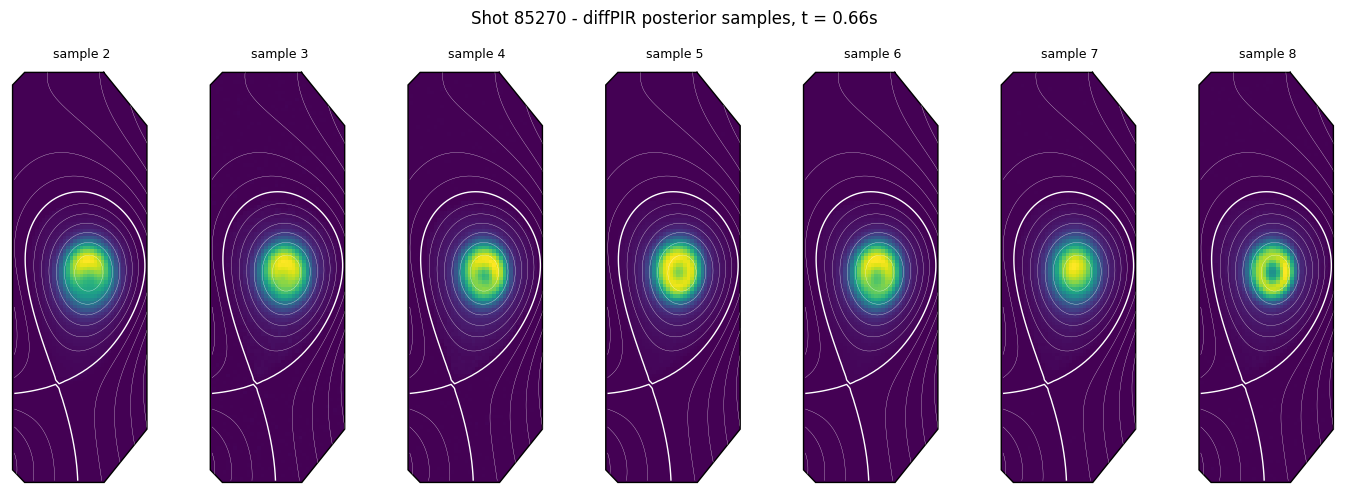

saved 8 eps files to results_images/real_data_posterior_samples/figs


In [4]:
# save one eps per posterior sample (same normalized units and vmin=0 as in the analysis notebook)
for n, sid in zip(sample_numbers, sample_ids):
    save_profile_eps(posterior[slice_idx, sid, 0], psi[slice_idx],
                     f"shot85270_{variant}_t{t_ms}ms_diffpir_sample{n}.eps", vmin=0)

# inline overview of what was saved
n_panels = len(sample_ids)
fig, ax = plt.subplots(1, n_panels, figsize=(2 * n_panels, 5))
for i, (n, sid) in enumerate(zip(sample_numbers, sample_ids)):
    tomo_plots.plot_profile(np.asarray(posterior[slice_idx, sid, 0]), tcv_plot_clip=True,
                            contour_image=psi[slice_idx], cmap="viridis", ax=ax[i],
                            colorbar=False, contour_color="w", vmin=0,
                            aspect=None, lcfs_width=1, lwidth=0.2)
    ax[i].set_title(f"sample {n}", fontsize=9)
    ax[i].axis('off')
fig.suptitle(f"Shot 85270 - diffPIR posterior samples, t = {times[slice_idx]:.2f}s")
plt.tight_layout()
plt.savefig(figs_dir / f"shot85270_{variant}_t{t_ms}ms_diffpir_samples_overview.eps",
            format='eps', bbox_inches="tight")
plt.show()

print(f"saved {n_panels + 1} eps files to {figs_dir}")